### Sensitivity analysis — results with vs. without outliers

On the project dataset (`data/raw/card_tiers.csv`, one row per hobby-box tier): does
removing the rare, IQR-flagged tiers give a *better* model of `est_value_usd` (card value)
as a function of `odds_pack` (rarity)?

This applies the Stage 07 homework method (`src/outliers.py`) to the project data. Outlier
definition and the flag-don't-remove decision are written up in
[`docs/outliers.md`](../docs/outliers.md).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))
from src import outliers

# Project dataset: one row per hobby-box tier. Regress tier value on rarity.
df = pd.read_csv(project_root / "data" / "raw" / "card_tiers.csv")
target_col, resp_col = "odds_pack", "est_value_usd"
df = df.dropna(subset=[target_col, resp_col]).reset_index(drop=True)  # LinearRegression rejects NaN

mask_iqr = outliers.detect_outliers_iqr(df[target_col])
mask_z = outliers.detect_outliers_zscore(df[target_col], threshold=3.0)
df_filtered = outliers.remove_outliers(df, mask_iqr)

print(f"regressing {resp_col} on {target_col}")
print(f"rows: {len(df)} all -> {len(df_filtered)} filtered "
      f"({int(mask_iqr.sum())} IQR outliers removed, {mask_iqr.mean():.1%})")
print(f"z-score (|z|>3) flags only {int(mask_z.sum())} ({mask_z.mean():.1%}) -- the rare "
      f"tiers inflate sigma and mask themselves")
df.loc[mask_iqr, ["tier_name", "tier_group", target_col, resp_col]].head(8)

regressing est_value_usd on odds_pack
rows: 181 all -> 152 filtered (29 IQR outliers removed, 16.0%)
z-score (|z|>3) flags only 3 (1.7%) -- the rare tiers inflate sigma and mask themselves


,tier_name,tier_group,odds_pack,est_value_usd
20,Red Refractor,parallel,4353.0,550.0
21,Red Wave Refractor,parallel,3420.0,550.0
22,FrozenFractor,parallel,4353.0,550.0
23,SuperFractor,parallel,21767.0,4000.0
52,Black Refractor,parallel,3022.0,300.0
54,Red Refractor,parallel,6054.0,550.0
55,Red Wave Refractor,parallel,3119.0,550.0
56,FrozenFractor,parallel,6054.0,550.0


#### Comparison table: summary stats

In [2]:
summ_all = df[target_col].describe()[["mean", "50%", "std"]].rename({"50%": "median"})
summ_filtered = df_filtered[target_col].describe()[["mean", "50%", "std"]].rename({"50%": "median"})

comp = pd.concat({"all": summ_all, "filtered_iqr": summ_filtered}, axis=1)
comp

,all,filtered_iqr
mean,3519.198895,435.177632
median,286.000000,173.500000
std,13156.920371,586.606235


#### Comparison table: regression fit

In [3]:
X_all, y_all = df[[target_col]].to_numpy(), df[resp_col].to_numpy()
X_filtered, y_filtered = df_filtered[[target_col]].to_numpy(), df_filtered[resp_col].to_numpy()

model_all = LinearRegression().fit(X_all, y_all)
model_filtered = LinearRegression().fit(X_filtered, y_filtered)

reg_results = pd.DataFrame({
    "slope": [model_all.coef_[0], model_filtered.coef_[0]],
    "intercept": [model_all.intercept_, model_filtered.intercept_],
    "r2": [model_all.score(X_all, y_all), model_filtered.score(X_filtered, y_filtered)],
    "mae": [mean_absolute_error(y_all, model_all.predict(X_all)),
            mean_absolute_error(y_filtered, model_filtered.predict(X_filtered))],
}, index=["all", "filtered_iqr"])
reg_results

,slope,intercept,r2,mae
all,0.028502,202.114695,0.198145,319.690713
filtered_iqr,0.146008,22.368491,0.678481,39.134360


#### Visual comparison: boxplot

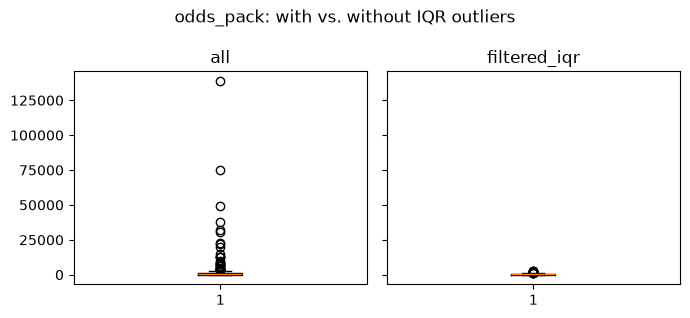

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2), sharey=True)
axes[0].boxplot(df[target_col]); axes[0].set_title("all")
axes[1].boxplot(df_filtered[target_col]); axes[1].set_title("filtered_iqr")
fig.suptitle(f"{target_col}: with vs. without IQR outliers")
fig.tight_layout()
plt.show()

#### Visual comparison: regression fit

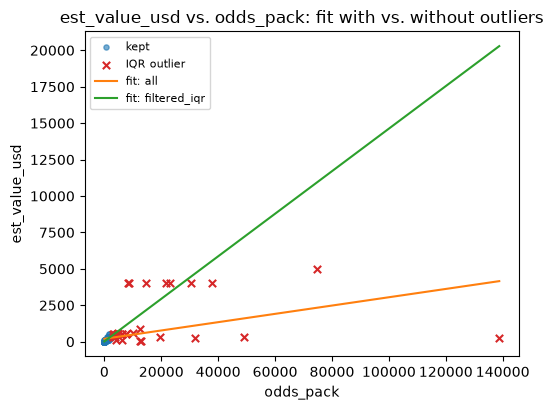

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 4.2))

outlier_pts = df.loc[mask_iqr]
ax.scatter(df_filtered[target_col], df_filtered[resp_col], s=14, alpha=0.6, label="kept", color="tab:blue")
ax.scatter(outlier_pts[target_col], outlier_pts[resp_col], s=28, marker="x", label="IQR outlier", color="tab:red")

xs = np.linspace(df[target_col].min(), df[target_col].max(), 100).reshape(-1, 1)
ax.plot(xs, model_all.predict(xs), color="tab:orange", label="fit: all")
ax.plot(xs, model_filtered.predict(xs), color="tab:green", label="fit: filtered_iqr")

ax.set_xlabel(target_col); ax.set_ylabel(resp_col)
ax.set_title(f"{resp_col} vs. {target_col}: fit with vs. without outliers")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

#### Takeaway

Removing the 29 IQR-flagged tiers raises the linear fit's R² from ~0.20 to ~0.68 — but that
is **not** evidence removal helped:

- the filtered model is scored on an easier, lower-variance subset (`odds_pack` std drops
  from ~13,000 to ~590), so R² is not comparable across the two;
- `est_value_usd ~ odds_pack` on the raw scale is the wrong functional form — rarity and
  value are roughly **log-log**, and the flagged SuperFractors / SSPs / low-numbered
  parallels are exactly the points a straight line cannot fit;
- those flagged tiers carry most of a box's expected value, so `remove_outliers` here would
  delete the rows that matter for the downstream EV calculation.

Decision: **flag, don't remove.** The IQR mask is kept as the `is_chase` feature in the
pipeline (Stage 07 / Stage 09). Full write-up: [`docs/outliers.md`](../docs/outliers.md).